In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import sklearn
import os

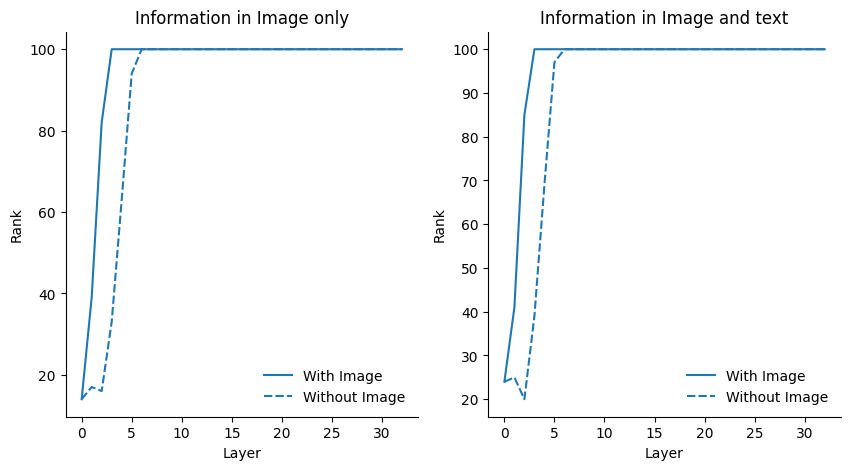

In [53]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
plot_df = pd.read_csv('./results/llava7B/svd/sample/svd_image_color_shape_gray_cylinder_7.csv', index_col=0)
plot_df['Mean_over'] = [i.split(' ')[0] for i in plot_df['Mean over']]

b = sns.lineplot(
    data=plot_df[plot_df['Mean_over']=='Text'],
    x='layers',
    y='0',
    # hue='Mean over',
    style='prompt',
    ax=ax[0] 
)

b.set_xlabel('Layer')
b.set_ylabel('Rank')
b.legend(frameon=False)
b.set_title('Information in Image only')

plot_df = pd.read_csv('./results/llava7B/svd/sample/svd_image_and_text_color_shape_gray_cylinder_7.csv', index_col=0)
plot_df['Mean_over'] = [i.split(' ')[0] for i in plot_df['Mean over']]

b = sns.lineplot(
    data=plot_df[plot_df['Mean_over']=='Text'],
    x='layers',
    y='0',
    # hue='Mean over',
    style='prompt',
    ax=ax[1] 
)

b.set_xlabel('Layer')
b.set_ylabel('Rank')
b.set_title('Information in Image and text')

b.legend(frameon=False)
sns.despine(top=True, right=True)

/tmp/ipykernel_7251/2741287072.py:26: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_7251/2741287072.py:26: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_7251/2741287072.py:26: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_7251/2741287072.py:26: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_7251/2741287072.py:26: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_7251/2741287072.py:26: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  b = sns.lineplot(
/tmp/ipykernel_7251/2741287072.py:26: UserWarning: The palette list has more values (4) 

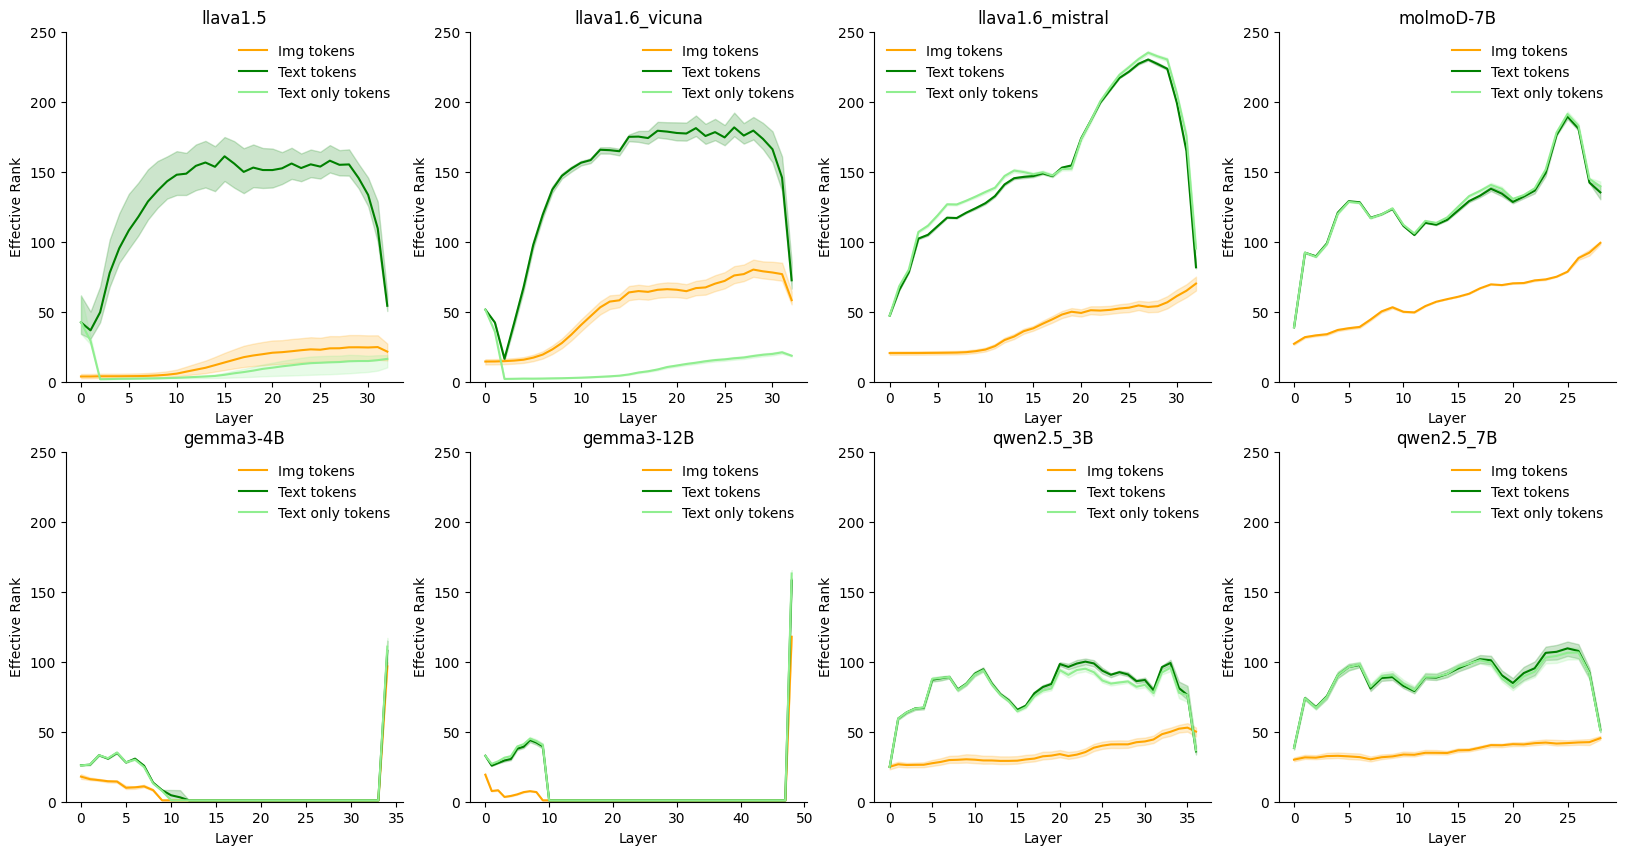

In [4]:
### All together
fig,ax = plt.subplots(2,4,figsize=(20,10))
ax = ax.flatten()
model_ls = ['llava1.5', 'llava1.6_vicuna', 'llava1.6_mistral', 'molmoD-7B', 'gemma3-4B', 'gemma3-12B', 'qwen2.5_3B', 'qwen2.5_7B']

for ax_idx, model in enumerate(model_ls):
    if model=='llava1.5':
        path = f'./results/{model}/svd/token/'
    else:
        path = f'./results/{model}/svd/'

    files = os.listdir(path)
    plot_df = []

    for idx, f in enumerate(files):
        df_ = pd.read_csv(path+f, index_col=0)
        if 'label' in df_.columns or 'sample' in df_.columns:
            df_ = df_.drop(['label','sample'],axis=1)

        df_ = df_.melt(['Mean over','contains'])
        df_['layers'] = df_['variable'].astype(int)
        plot_df = plot_df + [df_]
    plot_df = pd.concat(plot_df).reset_index()
        
        
    b = sns.lineplot(
        data=plot_df[(plot_df['Mean over']!='All tokens') & (plot_df['Mean over']!='Image only tokens')],
        # data=plot_df,
        x='layers',
        y='value',
        hue='Mean over',
        palette=['orange','green', 'lightgreen', 'red'],
        err_style='band',
        errorbar=lambda x: (x.min(), x.max()),
        ax=ax[ax_idx]
    )

    b.set(ylim=(0,250))
    b.set_xlabel('Layer')
    b.set_ylabel('Effective Rank')
    b.set_title(f'{model if model!="llava7B" else "llava1.5"}')
    b.legend(frameon=False)

sns.despine(top=True, right=True)



In [5]:
model_ls = ['llava1.5', 'llava1.6_vicuna', 'llava1.6_mistral', 'molmoD-7B', 'gemma3-4B', 'gemma3-12B', 'qwen2.5_3B', 'qwen2.5_7B']
auc_ls = []
for ax_idx, model in enumerate(model_ls):
    if model=='llava1.5':
        path = f'./results/{model}/svd/token/'
    else:
        path = f'./results/{model}/svd/'

    files = os.listdir(path)
    plot_df = []

    for idx, f in enumerate(files):
        df_ = pd.read_csv(path+f, index_col=0)
        if 'label' in df_.columns or 'sample' in df_.columns:
            df_ = df_.drop(['label','sample'],axis=1)

        df_ = df_.melt(['Mean over','contains'])
        df_['layers'] = df_['variable'].astype(int)
        plot_df = plot_df + [df_]
    plot_df = pd.concat(plot_df).reset_index()
    mean_df = plot_df.groupby(["Mean over", "layers"]).mean(numeric_only=True).reset_index()
    auc_text = sklearn.metrics.auc(mean_df[mean_df['Mean over']=='Text tokens']['layers']/mean_df['layers'].max(), 
                                mean_df[mean_df['Mean over']=='Text tokens']['value'])

    auc_img = sklearn.metrics.auc(mean_df[mean_df['Mean over']=='Img tokens']['layers']/mean_df['layers'].max(), 
                                mean_df[mean_df['Mean over']=='Img tokens']['value'])
    print(f"{model}: ", auc_text-auc_img)
    auc_ls = auc_ls + [auc_text-auc_img]


llava1.5:  118.57788467415473
llava1.6_vicuna:  93.47599844453124
llava1.6_mistral:  114.76172467968749
molmoD-7B:  68.26799382142858
gemma3-4B:  4.293801696470589
gemma3-12B:  6.086211485416667
qwen2.5_3B:  47.66852175555554
qwen2.5_7B:  53.30485114017856


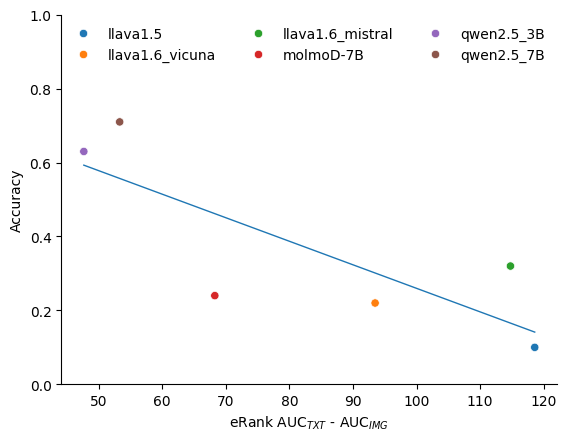

In [6]:
model_ls = ['llava1.5', 'llava1.6_vicuna', 'llava1.6_mistral', 'molmoD-7B', 'gemma3-4B', 'gemma3-12B', 'qwen2.5_3B', 'qwen2.5_7B']
acc_ls = [0.1, 0.22, 0.32,0.24,  0.47, 0.58, 0.63, 0.71]

plot_df = pd.DataFrame({
    'model': model_ls,
    'Accuracy': acc_ls,
    'AUC': auc_ls
})

plot_df = plot_df[~plot_df['model'].str.contains('gemma')]

size_ls = ['7B', '7B', '7B', '4B', '3B', '7B']

b = sns.scatterplot(data=plot_df, x='AUC', y='Accuracy', hue='model')
sns.regplot(data=plot_df, x="AUC", y="Accuracy", ci=None,
            scatter=False, ax=b, line_kws={"lw":1})

b.legend(frameon=False, ncols=3)
b.set(ylim=(0,1))
b.set_ylabel('Accuracy')
b.set_xlabel('eRank AUC$_{TXT}$ - AUC$_{IMG}$')
sns.despine(top=True, right=True)



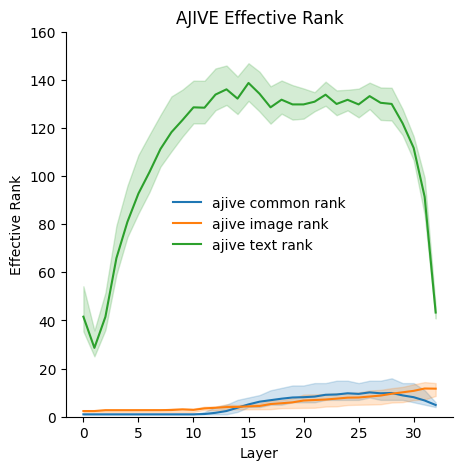

In [10]:
### All together
fig,ax = plt.subplots(1,1,figsize=(5,5))
plot_df = []

# add all the files together
files = os.listdir(f'./results/llava7B/svd/ajive/')

for idx,f in enumerate(files):
    df_ = pd.read_csv(f'./results/llava7B/svd/ajive/{f}', index_col=0)
    df_ = df_.melt(['Mean over','contains', 'label','sample'])
    df_['layers'] = df_['variable'].astype(int)
    plot_df = plot_df + [df_]
plot_df = pd.concat(plot_df).reset_index()

b = sns.lineplot(
    data=plot_df[plot_df['Mean over'].str.contains('ajive')],
    x='layers',
    y='value',
    hue='Mean over',
    err_style='band',
    errorbar=lambda x: (x.min(), x.max()),
    ax=ax
)


b.set(ylim=(0,160))
b.set_xlabel('Layer')
b.set_ylabel('Effective Rank')
b.set_title(f'AJIVE Effective Rank')
b.legend(frameon=False)
sns.despine(top=True, right=True)



In [18]:
prediction_df = pd.read_csv('./results/llava7B/MATE_prediction.csv')

prediction_df[prediction_df['prediction_lower']!=prediction_df['gold_reference_lower']]

4933/5500, 1-4933/5500

(0.8969090909090909, 0.10309090909090912)

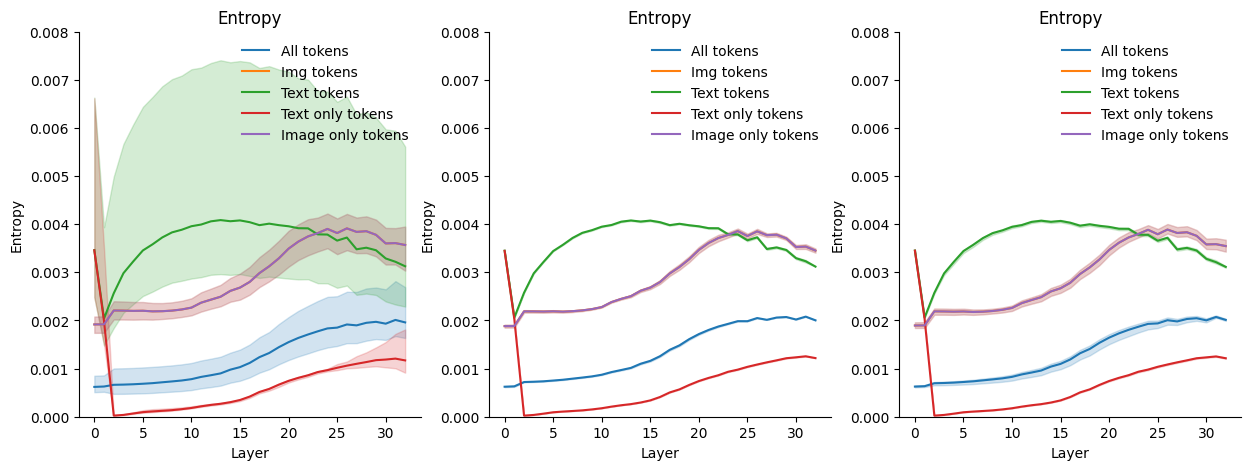

In [5]:
### All together
fig,ax = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15,5)
)
plot_df = []

files = os.listdir(f'./results/llava7B/svd/entropy/')
for f in files:
    df_ = pd.read_csv(f'./results/llava7B/svd/entropy/{f}', index_col=0)
    df_ = df_.melt(['Token type','contains', 'label','sample'])
    df_['layers'] = df_['variable'].astype(int)
    plot_df = plot_df + [df_]
plot_df = pd.concat(plot_df).reset_index()


b = sns.lineplot(
    data=plot_df,
    x='layers',
    y='value',
    hue='Token type',
    err_style='band',
    errorbar=lambda x: (x.min(), x.max()),
    ax=ax[0]
)


b.set(ylim=(0,0.008))
b.set_xlabel('Layer')
b.set_ylabel('Entropy')
b.set_title('Entropy')
b.legend(frameon=False)

plot_df = pd.read_csv('./results/llava7B/svd/entropy//T_entropy_image_and_text_gray_cylinder_7.csv', index_col=0)
plot_df = plot_df.melt(['Token type','contains', 'label','sample'])
plot_df['layers'] = plot_df['variable'].astype(int)

b = sns.lineplot(
    data=plot_df,
    x='layers',
    y='value',
    hue='Token type',
    err_style='band',
    errorbar=lambda x: (x.min(), x.max()),
    ax=ax[1]
)



b.set(ylim=(0,0.008))
b.set_xlabel('Layer')
b.set_ylabel('Entropy')
b.set_title('Entropy')
b.legend(frameon=False)


plot_df = pd.read_csv('./results/llava7B/svd/entropy//entropy_image_and_text_gray_cylinder_7.csv', index_col=0)
plot_df = plot_df.melt(['Token type','contains', 'label','sample'])
plot_df['layers'] = plot_df['variable'].astype(int)

b = sns.lineplot(
    data=plot_df,
    x='layers',
    y='value',
    hue='Token type',
    err_style='band',
    errorbar=lambda x: (x.min(), x.max()),
    ax=ax[2]
)

b.set(ylim=(0,0.008))
b.set_xlabel('Layer')
b.set_ylabel('Entropy')
b.set_title('Entropy')
b.legend(frameon=False)
sns.despine(top=True, right=True)